### Importation des librairies 

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import math
import csv
import os
import pickle
from matplotlib.ticker import MultipleLocator
import xarray as xr

### Importation des fichiers 3D

In [16]:
data_cli = xr.open_dataset("3D/MESONH_RCE_small300_3D_cli.nc") #glace nuageuse
data_clw = xr.open_dataset("3D/MESONH_RCE_small300_3D_clw.nc") #eau liquide nuageuse
data_hur = xr.open_dataset("3D/MESONH_RCE_small300_3D_hur.nc") #humidité relative
data_hus = xr.open_dataset("3D/MESONH_RCE_small300_3D_hus.nc") #humidité spécifique
data_pa = xr.open_dataset("3D/MESONH_RCE_small300_3D_pa.nc") #pression atmosphérique 
data_pli = xr.open_dataset("3D/MESONH_RCE_small300_3D_pli.nc") #glace précipitante
data_plw = xr.open_dataset("3D/MESONH_RCE_small300_3D_plw.nc") #eau liquide précipitante
data_ta = xr.open_dataset("3D/MESONH_RCE_small300_3D_ta.nc") #température atmosphérique
data_tntr = xr.open_dataset("3D/MESONH_RCE_small300_3D_tntr.nc") #tendance des températures(radiative)
data_tntrl = xr.open_dataset("3D/MESONH_RCE_small300_3D_tntrl.nc") #tendance des températures(radiative longwave)
data_tntrs = xr.open_dataset("3D/MESONH_RCE_small300_3D_tntrs.nc") #tendance des températures(radiative shortwave)
data_ua = xr.open_dataset("3D/MESONH_RCE_small300_3D_ua.nc") #vitesse de l air
data_va = xr.open_dataset("3D/MESONH_RCE_small300_3D_va.nc") #vitesse de l air
data_wa = xr.open_dataset("3D/MESONH_RCE_small300_3D_wa.nc") #vitesse de l air verticale

In [17]:
print(data_clw)
print(data_tntr)

<xarray.Dataset> Size: 296MB
Dimensions:   (time: 100, altitude: 74, y: 100, x: 100)
Coordinates:
  * time      (time) timedelta64[ns] 800B 75 days 06:00:00 ... 100 days 00:00:00
  * altitude  (altitude) float32 296B 0.0 37.0 112.0 ... 3.2e+04 3.25e+04
  * y         (y) float32 400B 1.0 2.0 3.0 4.0 5.0 ... 96.0 97.0 98.0 99.0 100.0
  * x         (x) float32 400B 1.0 2.0 3.0 4.0 5.0 ... 96.0 97.0 98.0 99.0 100.0
Data variables:
    clw       (time, altitude, y, x) float32 296MB ...
<xarray.Dataset> Size: 296MB
Dimensions:   (time: 100, altitude: 74, y: 100, x: 100)
Coordinates:
  * time      (time) timedelta64[ns] 800B 75 days 06:00:00 ... 100 days 00:00:00
  * altitude  (altitude) float32 296B 0.0 37.0 112.0 ... 3.2e+04 3.25e+04
  * y         (y) float32 400B 1.0 2.0 3.0 4.0 5.0 ... 96.0 97.0 98.0 99.0 100.0
  * x         (x) float32 400B 1.0 2.0 3.0 4.0 5.0 ... 96.0 97.0 98.0 99.0 100.0
Data variables:
    tntr      (time, altitude, y, x) float32 296MB ...


On a une grille horizontale de 100 par 100. L'altitude est découpée en 74 couches et le modèle a enregistré 100 moments différents.

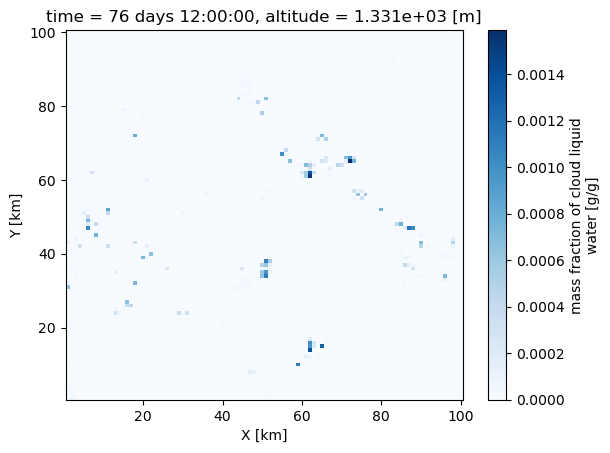

In [18]:
data_clw['clw'].isel(time=5, altitude=10).plot(cmap = 'Blues')

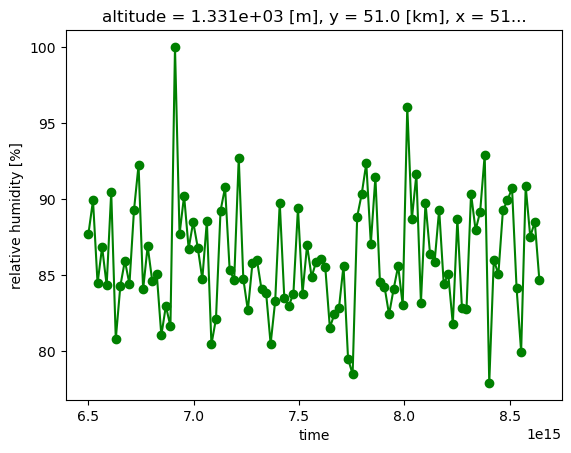

In [19]:
data_hur['hur'].isel(x=50, y=50, altitude=10).plot(marker='o', color='green')

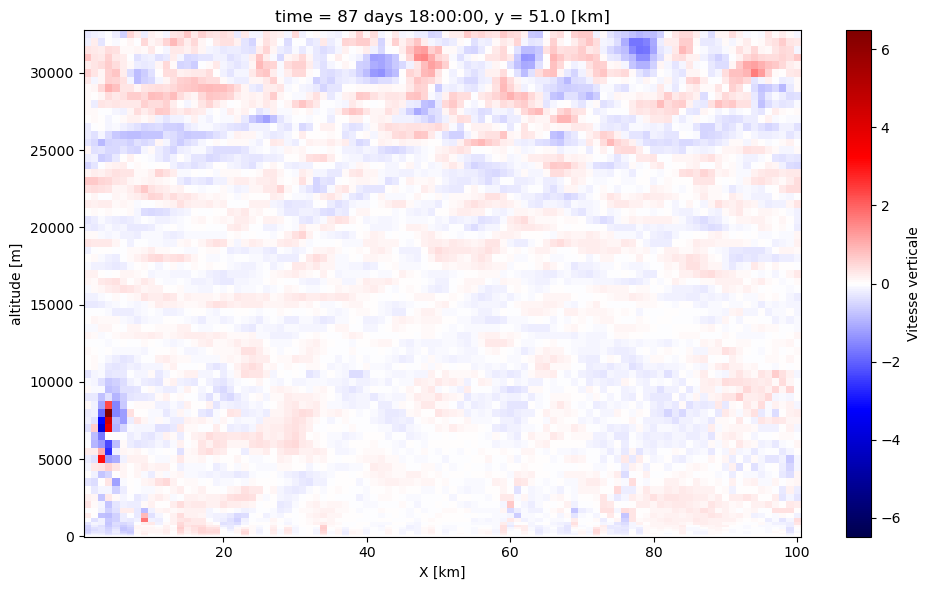

In [20]:
time_index = 50
y_index = 50
coupe_verticale_wa = data_wa['wa'].isel(time=time_index, y=y_index)
plt.figure(figsize=(10,6))
plot = coupe_verticale_wa.plot(x='x', y='altitude', cmap='seismic', cbar_kwargs={'label':'Vitesse verticale'})
plt.tight_layout()
plt.show()

### Exemple 1D

In [21]:
data_clw_1D = xr.open_dataset("1D/MESONH_RCE_small300_1D_clw_avg.nc") #eau liquide nuageuse
print(data_clw_1D)

<xarray.Dataset> Size: 730kB
Dimensions:   (time: 2400, altitude: 74)
Coordinates:
  * time      (time) timedelta64[ns] 19kB 01:00:00.000107285 ... 100 days 00:...
  * altitude  (altitude) float32 296B 0.0 37.0 112.0 ... 3.2e+04 3.25e+04
Data variables:
    clw_avg   (time, altitude) float32 710kB ...


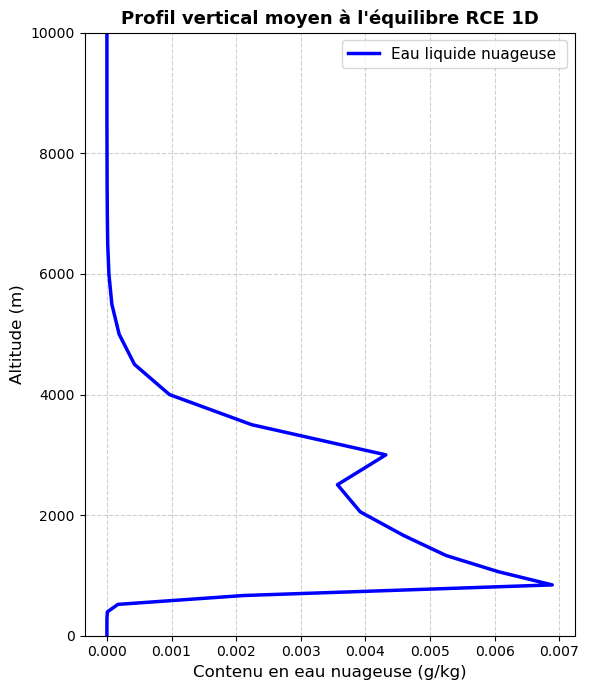

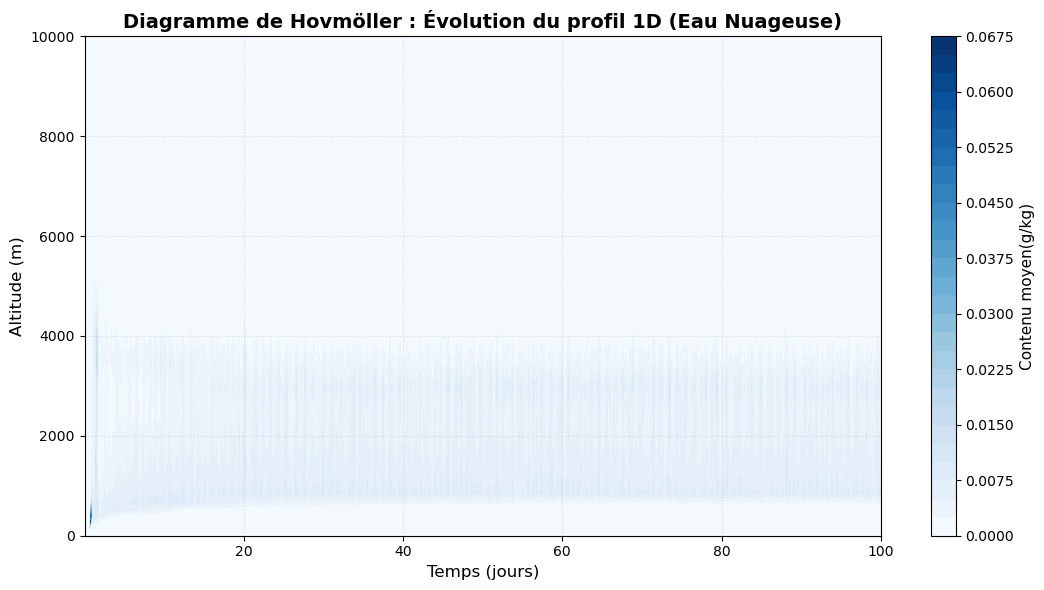

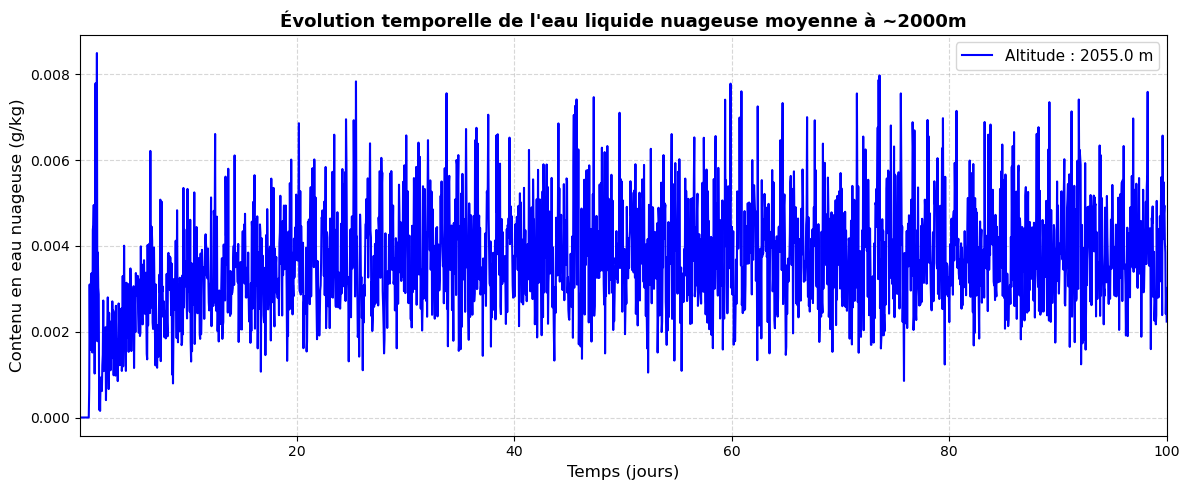

In [22]:
# Extraction de la variable de l'eau liquide nuageuse 
clw_1d = data_clw_1D['clw_avg']

# état stationnaire ou l'équilibre final, 20 derniers pas de temps 
clw_equilibrium = clw_1d.isel(time=slice(-200, None)).mean(dim='time')

# =============================================================================
# REPRÉSENTATION DU PROFIL VERTICAL MOYEN (ÉQUILIBRE)
# =============================================================================
plt.figure(figsize=(6, 7))

# Multiplication par 1000 pour convertir les kg/kg de l'eau nuageuse en g/kg
plt.plot(clw_equilibrium * 1000, clw_1d.altitude, color='blue', lw=2.5, label=r'Eau liquide nuageuse ')

plt.xlabel('Contenu en eau nuageuse (g/kg)', fontsize=12)
plt.ylabel('Altitude (m)', fontsize=12)
plt.title('Profil vertical moyen à l\'équilibre RCE 1D', fontsize=13, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11, loc='upper right')
plt.ylim(0, 10000)
plt.tight_layout()
plt.show()

# =============================================================================
# DIAGRAMME DE HOVMÖLLER (ÉVOLUTION TEMPORELLE DU PROFIL 1D)
# =============================================================================

plt.figure(figsize=(11, 6))

# Conversion de l'axe du temps (timedelta64[ns]) en jours 
temps_jours = clw_1d.time.astype('float64') / (1e9 * 3600 * 24)

# Génération des contours remplis (Axe X : Temps, Axe Y : Altitude)
cf = plt.contourf(temps_jours, clw_1d.altitude, clw_1d.T * 1000, levels=30, cmap='Blues')

# Ajout de la barre d'échelle des couleurs
cb = plt.colorbar(cf)
cb.set_label('Contenu moyen(g/kg)', fontsize=11)

plt.xlabel('Temps (jours)', fontsize=12)
plt.ylabel('Altitude (m)', fontsize=12)
plt.title('Diagramme de Hovmöller : Évolution du profil 1D (Eau Nuageuse)', fontsize=14, fontweight='bold')
plt.grid(True, linestyle=':', alpha=0.4)
plt.ylim(0, 10000)
plt.tight_layout()
plt.show()



# =============================================================================
# TRACÉ DE L'ÉVOLUTION TEMPORELLE (JOUR APRÈS JOUR)
# =============================================================================
# Sélection de la couche la plus proche de 2000 mètres (méthode 'nearest')
clw_2000m = clw_1d.sel(altitude=2000, method='nearest')

altitude_exacte = float(clw_2000m.altitude)
temps_jours = clw_1d.time.astype('float64') / (1e9 * 3600 * 24)

plt.figure(figsize=(12, 5))

# Multiplication par 1000 pour convertir les kg/kg en g/kg
plt.plot(temps_jours, clw_2000m.values * 1000, color='blue', lw=1.5, label=f'Altitude : {altitude_exacte:.1f} m')

plt.xlabel('Temps (jours)', fontsize=12)
plt.ylabel('Contenu en eau nuageuse (g/kg)', fontsize=12)
plt.title(f'Évolution temporelle de l\'eau liquide nuageuse moyenne à ~2000m', fontsize=13, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11)

# Ajustement automatique des limites de l'axe X pour couvrir toute la simulation
plt.xlim(temps_jours.min(), temps_jours.max())

plt.tight_layout()
plt.show()

### Tracé du flux  de quantité de mouvement et de sa dérivée 

Chargement des fichiers NetCDF...
Données chargées avec succès.
Forme des fichiers : (100, 74, 100, 100) (Temps, Altitude, Y, X)
Calcul des moyennes horizontales et des anomalies (primes)...
Calcul des flux de Reynolds...
altitude
Moyenne temporelle finale...
Génération des graphiques...


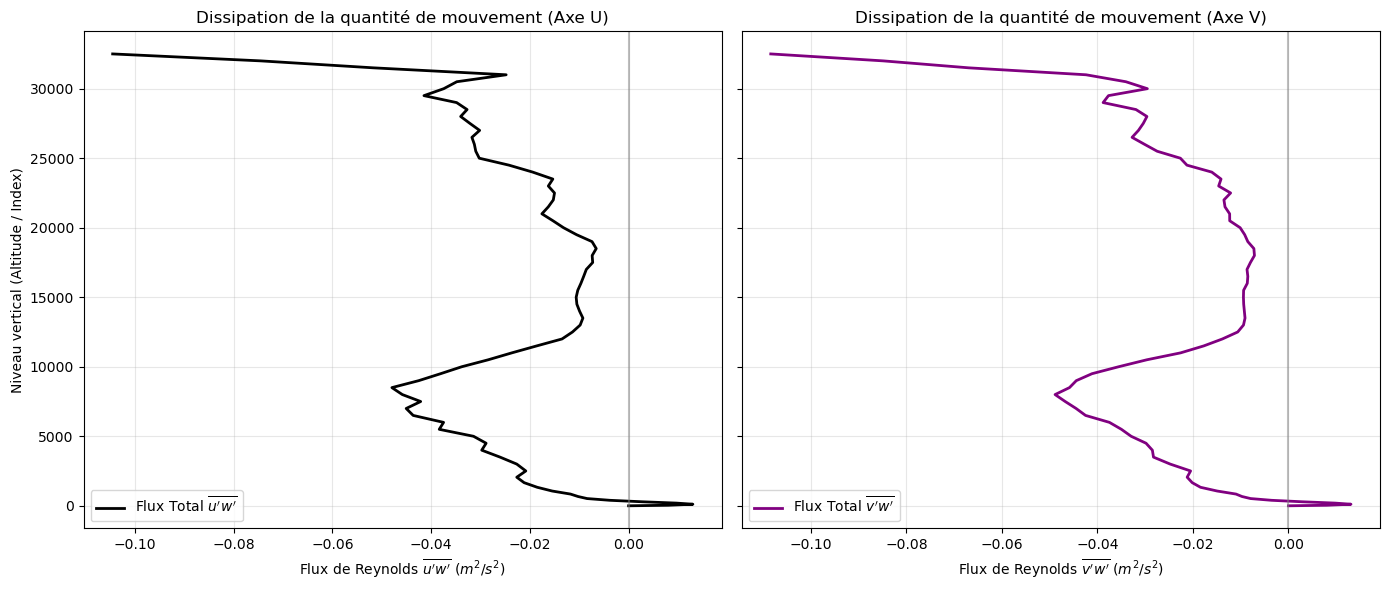

In [23]:
# =============================================================================
# 1. CHARGEMENT DES DONNÉES
# =============================================================================
print("Chargement des fichiers NetCDF...")

# Chargement des vents (U: zonal, V: méridien, W: vertical)
ds_ua = xr.open_dataset("3D/MESONH_RCE_small300_3D_ua.nc")
ds_va = xr.open_dataset("3D/MESONH_RCE_small300_3D_va.nc")
ds_wa = xr.open_dataset("3D/MESONH_RCE_small300_3D_wa.nc")

# Extraction des DataArrays spécifiques 
u = ds_ua["ua"]
v = ds_va["va"]
w = ds_wa["wa"]

print("Données chargées avec succès.")
print(f"Forme des fichiers : {u.shape} (Temps, Altitude, Y, X)")

# =============================================================================
# 2. DÉCOMPOSITION DE REYNOLDS (Calcul des moyennes et des anomalies)
# =============================================================================
print("Calcul des moyennes horizontales et des anomalies (primes)...")

# Étape A: Calcul de la moyenne horizontale sur les axes 'x' et 'y'
# L'état moyen dépend uniquement du temps (time) et de la hauteur (level/altitude)
u_mean = u.mean(dim=["x", "y"])
v_mean = v.mean(dim=["x", "y"])
w_mean = w.mean(dim=["x", "y"])

# Étape B: Calcul des fluctuations turbulentes (Anomalies = Valeur - Moyenne)
u_prime = u - u_mean
v_prime = v - v_mean
w_prime = w - w_mean

# =============================================================================
# 3. CALCUL DES FLUX TURBULENTS DE QUANTITÉ DE MOUVEMENT
# =============================================================================
print("Calcul des flux de Reynolds...")

# Flux instantanés en chaque point de la grille 3D
flux_u_3d = u_prime * w_prime
flux_v_3d = v_prime * w_prime

# Flux total moyen (moyenne horizontale)
# On obtient un profil vertical qui évolue au cours du temps
flux_u_total_profile = flux_u_3d.mean(dim=["x", "y"])
flux_v_total_profile = flux_v_3d.mean(dim=["x", "y"])

print(u.dims[1])

# =============================================================================
# 5. MOYENNE TEMPORELLE ET EXTRACTION DE L'ALTITUDE
# =============================================================================
print("Moyenne temporelle finale...")

# On fait la moyenne sur tout le contenu temporel pour avoir le comportement stationnaire
flux_u_total_final = flux_u_total_profile.mean(dim="time")
flux_v_total_final = flux_v_total_profile.mean(dim="time")

axe_z = u["altitude"].values

# =============================================================================
# 6. VISUALISATION DES RÉSULTATS (TRACÉ DES PROFILS VERTICAUX)
# =============================================================================
print("Génération des graphiques...")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Graphique 1 : Profils de flux pour la composante U (Zonale)
ax1.plot(
    flux_u_total_final,
    axe_z,
    label="Flux Total $\\overline{u'w'}$",
    color="black",
    linewidth=2,
)

ax1.axvline(0, color="grey", linestyle="-", alpha=0.5)
ax1.set_title("Dissipation de la quantité de mouvement (Axe U)")
ax1.set_xlabel("Flux de Reynolds $\\overline{u'w'}$ ($m^2/s^2$)")
ax1.set_ylabel("Niveau vertical (Altitude / Index)")
ax1.grid(True, alpha=0.3)
ax1.legend()

# Graphique 2 : Profil de flux pour la composante V (Méridienne)
ax2.plot(
    flux_v_total_final,
    axe_z,
    label="Flux Total $\\overline{v'w'}$",
    color="purple",
    linewidth=2,
)
ax2.axvline(0, color="grey", linestyle="-", alpha=0.5)
ax2.set_title("Dissipation de la quantité de mouvement (Axe V)")
ax2.set_xlabel("Flux de Reynolds $\\overline{v'w'}$ ($m^2/s^2$)")
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()


Premier pic : la couche limite. Observation d'un flux de quantité de mouvement vers le bas qui vient copenser l'énergie perdu par frottement au niveau de la surface terrestre. Analyse du reste ? Très gros pic en haut ?

Calcul des tendances (pertes et gains de quantité de mouvement)...


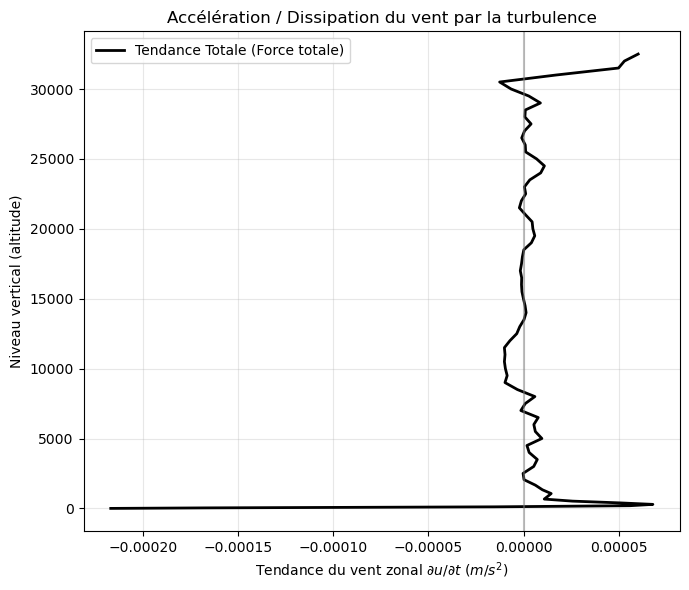

In [24]:
# =============================================================================
# 7. CALCUL DE LA DISSIPATION / TENDANCE (DÉPRIVÉE VERTICALE)
# =============================================================================
print("Calcul des tendances (pertes et gains de quantité de mouvement)...")

nom_axe_z=u.dims[1]
tendance_u_total = -flux_u_total_final.differentiate(nom_axe_z)

# =============================================================================
# 8. TRACÉ DES TENDANCES
# =============================================================================
plt.figure(figsize=(7, 6))

plt.plot(
    tendance_u_total,
    axe_z,
    label="Tendance Totale (Force totale)",
    color="black",
    linewidth=2,
)

plt.axvline(0, color="grey", linestyle="-", alpha=0.5)
plt.title("Accélération / Dissipation du vent par la turbulence")
plt.xlabel("Tendance du vent zonal $\\partial u / \\partial t$ ($m/s^2$)")
plt.ylabel(f"Niveau vertical ({nom_axe_z})")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()